# Module 4 - Week 6 Module Demo: Supervised Learning
## Live Demo Notebook

**Scenario:** You're a data scientist at Access Bank Nigeria.
The credit risk team wants the best possible loan analysis system.

Using 500 historical loan records, we apply all six Week 6 topics in one session:

| Section | Topic covered |
|---|---|
| 1. Predict default amount | Topic 1 - Linear Regression |
| 2. Classify high-risk applicants | Topic 2 - Logistic Regression |
| 3. Build an interpretable compliance tree | Topic 3 - Decision Trees |
| 4. Improve with Random Forest | Topic 4 - Random Forests |
| 5. Compare all models properly | Topic 5 - Model Evaluation Metrics |
| 6. Find the best configuration | Topic 6 - Cross-Validation & GridSearchCV |

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    accuracy_score, classification_report,
    f1_score, recall_score, roc_auc_score,
    confusion_matrix, roc_curve, auc
)

sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('access_bank_loans.csv')
print('Shape:', df.shape)
print(f'High risk rate: {df["high_risk"].mean():.1%}')
df.head()

Shape: (500, 9)
High risk rate: 7.2%


,age,income,loan_amount,credit_score,employment_years,num_dependants,debt_ratio,default_amount,high_risk
0,61,326044,2719566,385,8,3,0.695,1238000,0
1,49,695677,1950114,488,17,2,0.234,784000,0
2,34,1135464,2724088,734,13,1,0.200,403000,0
3,45,521163,6421066,686,12,1,1.027,1996000,0
4,42,739402,1232896,437,27,0,0.139,410000,0


In [2]:
# Features shared across all models
FEATURES = ['age', 'income', 'loan_amount', 'credit_score',
            'employment_years', 'num_dependants', 'debt_ratio']

X = df[FEATURES]

# Two different targets for regression vs classification
y_reg  = df['default_amount']   # continuous - for Linear Regression
y_clf  = df['high_risk']        # binary - for classification models

# Hold-out splits
X_train, X_test, yr_train, yr_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
X_train_c, X_test_c, yc_train, yc_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f'Regression split:     train={len(X_train)} test={len(X_test)}')
print(f'Classification split: train={len(X_train_c)} test={len(X_test_c)}')

Regression split:     train=400 test=100
Classification split: train=400 test=100


---
# Section 1 - Predict Default Amount
## Topic 1: Linear Regression

In [3]:
# Build and evaluate a Linear Regression model
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression()),
])
lr_pipe.fit(X_train, yr_train)
yr_pred = lr_pipe.predict(X_test)

mae  = mean_absolute_error(yr_test, yr_pred)
r2   = r2_score(yr_test, yr_pred)
mean_da = yr_test.mean()

print('=== Linear Regression: Predicting Default Amount ===')
print(f'MAE:  NGN {mae:,.0f}  ({mae/mean_da*100:.0f}% of mean default amount)')
print(f'R²:   {r2:.3f}  (model explains {r2*100:.0f}% of variation)')

# Extract coefficients
lr_model = lr_pipe.named_steps['model']
coef_df = pd.Series(lr_model.coef_, index=FEATURES).sort_values(ascending=False)
print()
print('Feature effects on default amount (standardised coefficients):')
for feat, val in coef_df.items():
    direction = 'increases' if val > 0 else 'decreases'
    print(f'  {feat:<20}: {direction} default amount (coef={val:.0f})')

=== Linear Regression: Predicting Default Amount ===
MAE:  NGN 604,584  (33% of mean default amount)
R²:   0.896  (model explains 90% of variation)

Feature effects on default amount (standardised coefficients):
  debt_ratio          : increases default amount (coef=3746702)
  loan_amount         : increases default amount (coef=600393)
  income              : increases default amount (coef=424836)
  age                 : increases default amount (coef=93211)
  employment_years    : decreases default amount (coef=-66744)
  num_dependants      : decreases default amount (coef=-137657)
  credit_score        : decreases default amount (coef=-340848)


---
# Section 2 - Classify High-Risk Applicants
## Topic 2: Logistic Regression

In [4]:
log_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)),
])
log_pipe.fit(X_train_c, yc_train)
log_pred  = log_pipe.predict(X_test_c)
log_proba = log_pipe.predict_proba(X_test_c)[:, 1]

print('=== Logistic Regression: Classify High-Risk Applicants ===')
print(classification_report(yc_test, log_pred, target_names=['Low Risk', 'High Risk']))

# Probability output for top 5 highest-risk predictions
top_risk = pd.DataFrame({
    'prob_high_risk': log_proba,
    'actual':         yc_test.values
}).sort_values('prob_high_risk', ascending=False).head(5)
print('Top 5 highest-risk applicants by probability:')
print(top_risk.to_string(index=False))

=== Logistic Regression: Classify High-Risk Applicants ===
              precision    recall  f1-score   support

    Low Risk       0.99      0.88      0.93        93
   High Risk       0.35      0.86      0.50         7

    accuracy                           0.88       100
   macro avg       0.67      0.87      0.72       100
weighted avg       0.94      0.88      0.90       100

Top 5 highest-risk applicants by probability:
 prob_high_risk  actual
       0.999998       1
       0.997678       0
       0.993538       1
       0.965495       0
       0.949824       0


---
# Section 3 - Interpretable Compliance Tree
## Topic 3: Decision Trees

In [5]:
dt = DecisionTreeClassifier(
    max_depth=4, min_samples_leaf=8, random_state=42
)
dt.fit(X_train_c, yc_train)
dt_pred = dt.predict(X_test_c)

print('=== Decision Tree: Interpretable Compliance Rules ===')
print(f'Test accuracy: {accuracy_score(yc_test, dt_pred):.2%}')
print(f'Test recall (High Risk): {recall_score(yc_test, dt_pred):.2%}')
print()
print('Decision rules (printable for CBN compliance):')
print()
print(export_text(dt, feature_names=FEATURES))

=== Decision Tree: Interpretable Compliance Rules ===
Test accuracy: 90.00%
Test recall (High Risk): 14.29%

Decision rules (printable for CBN compliance):

|--- debt_ratio <= 1.48
|   |--- employment_years <= 3.50
|   |   |--- credit_score <= 388.00
|   |   |   |--- class: 0
|   |   |--- credit_score >  388.00
|   |   |   |--- credit_score <= 489.00
|   |   |   |   |--- class: 0
|   |   |   |--- credit_score >  489.00
|   |   |   |   |--- class: 0
|   |--- employment_years >  3.50
|   |   |--- class: 0
|--- debt_ratio >  1.48
|   |--- credit_score <= 452.50
|   |   |--- credit_score <= 383.00
|   |   |   |--- class: 1
|   |   |--- credit_score >  383.00
|   |   |   |--- class: 1
|   |--- credit_score >  452.50
|   |   |--- debt_ratio <= 2.32
|   |   |   |--- class: 0
|   |   |--- debt_ratio >  2.32
|   |   |   |--- credit_score <= 633.50
|   |   |   |   |--- class: 1
|   |   |   |--- credit_score >  633.50
|   |   |   |   |--- class: 0



---
# Section 4 - Improve Accuracy with Random Forest
## Topic 4: Random Forests

=== Random Forest ===
Test accuracy: 93.00%
Test recall (High Risk): 14.29%



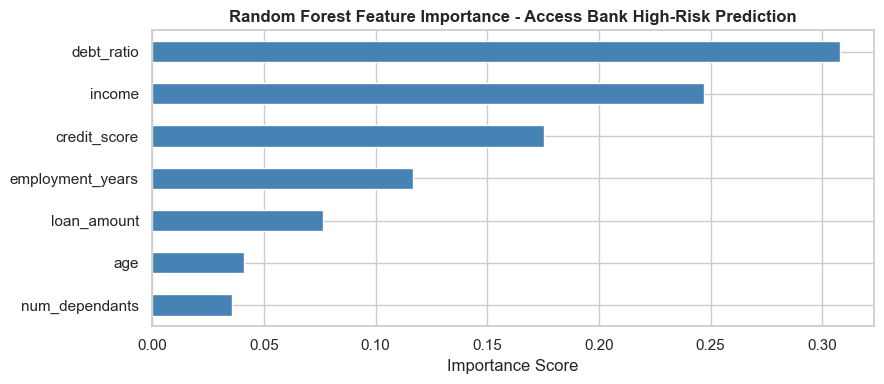

Top driver of high-risk classification: debt_ratio


In [8]:
rf = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train_c, yc_train)
rf_pred  = rf.predict(X_test_c)
rf_proba = rf.predict_proba(X_test_c)[:, 1]

print('=== Random Forest ===')
print(f'Test accuracy: {accuracy_score(yc_test, rf_pred):.2%}')
print(f'Test recall (High Risk): {recall_score(yc_test, rf_pred):.2%}')
print()

# Feature importance
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 4))
imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Random Forest Feature Importance - Access Bank High-Risk Prediction',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top driver of high-risk classification:', imp.index[-1])

---
# Section 5 - Compare All Models
## Topic 5: Model Evaluation Metrics

In [7]:
# Compare all three classification models
models_clf = {
    'Logistic Regression': (log_pred, log_proba),
    'Decision Tree':        (dt_pred,  dt.predict_proba(X_test_c)[:, 1]),
    'Random Forest':        (rf_pred,  rf_proba),
}

print(f'{"Model":<22} {"Acc":>8} {"Rec(HR)":>10} {"F1(HR)":>9} {"AUC":>8}')
print('-' * 62)
for name, (pred, proba) in models_clf.items():
    acc = accuracy_score(yc_test, pred)
    rec = recall_score(yc_test, pred, zero_division=0)
    f1  = f1_score(yc_test, pred, zero_division=0)
    try:
        auc_val = roc_auc_score(yc_test, proba)
    except:
        auc_val = 0
    print(f'{name:<22} {acc:>7.1%} {rec:>10.1%} {f1:>8.1%} {auc_val:>8.3f}')

Model                       Acc    Rec(HR)    F1(HR)      AUC
--------------------------------------------------------------
Logistic Regression      88.0%      85.7%    50.0%    0.920
Decision Tree            90.0%      14.3%    16.7%    0.654
Random Forest            93.0%      14.3%    22.2%    0.927


In [ ]:
# ROC curves for all three models
fig, ax = plt.subplots(figsize=(8, 6))

colours = ['steelblue', 'coral', 'seagreen']
for (name, (pred, proba)), colour in zip(models_clf.items(), colours):
    try:
        fpr, tpr, _ = roc_curve(yc_test, proba)
        auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colour, linewidth=2,
                label=f'{name} (AUC={auc_val:.3f})')
    except:
        pass

ax.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves - Access Bank High-Risk Classification',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

---
# Section 6 - Find the Best Configuration
## Topic 6: Cross-Validation & GridSearchCV

In [ ]:
# First: show CV stability vs single split
rf_stable = RandomForestClassifier(n_estimators=100, max_depth=10,
                                    class_weight='balanced', random_state=42, n_jobs=-1)

cv_scores = cross_val_score(rf_stable, X, y_clf, cv=5, scoring='f1', n_jobs=-1)
print('5-Fold CV F1 scores for Random Forest:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.3f}')
print(f'\nMean F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

In [ ]:
# GridSearchCV to find the best Random Forest configuration
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [5, 8, 12],
    'min_samples_leaf': [1, 3, 5],
}
# 3 × 3 × 3 = 27 combinations × 5 folds = 135 fits

gs = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0,
)
gs.fit(X_train_c, yc_train)

print('=== GridSearchCV Results ===')
print(f'Best parameters: {gs.best_params_}')
print(f'Best CV F1:      {gs.best_score_:.3f}')

In [ ]:
# Final evaluation on the held-out test set
best_rf = gs.best_estimator_
best_pred  = best_rf.predict(X_test_c)
best_proba = best_rf.predict_proba(X_test_c)[:, 1]

print('=== FINAL MODEL: Best Random Forest ===')
print(f'Best parameters: {gs.best_params_}')
print()
print(f'CV F1:   {gs.best_score_:.3f}')
print(f'Test F1: {f1_score(yc_test, best_pred, zero_division=0):.3f}')
print(f'Test AUC: {roc_auc_score(yc_test, best_proba):.3f}')
print()
print(classification_report(yc_test, best_pred, target_names=['Low Risk', 'High Risk']))

---
## Week 6 Module Demo Summary

| Topic | Algorithm | Task | Key result |
|---|---|---|---|
| 1 - Linear Regression | LinearRegression | Predict default amount | MAE, R², coefficient interpretation |
| 2 - Logistic Regression | LogisticRegression | Classify high-risk | Probability output, threshold tuning |
| 3 - Decision Trees | DecisionTreeClassifier | Compliance rules | Printable audit trail |
| 4 - Random Forests | RandomForestClassifier | Improve accuracy | Better F1, stable feature importance |
| 5 - Evaluation Metrics | All classifiers | Compare properly | F1, AUC, ROC curve |
| 6 - CV & Tuning | GridSearchCV | Find best config | Best parameters via 5-fold CV |

**The business outcome:** Access Bank now has:
1. A regression model estimating the likely default amount for each application
2. A classification system with three tiers: Logistic (probability), Decision Tree (compliance), Random Forest (accuracy)
3. Properly evaluated and tuned models - no accuracy trap, no data leakage

**Week 6 complete.**

In [9]:
import pickle

# Save the Random Forest model
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

print("Model saved as 'random_forest_model.pkl'")

Model saved as 'random_forest_model.pkl'
